## Skeleton-Transformer v3 — Crop-Then-Pose Re-Extraction

Re-extracts skeleton data with four quality improvements, then trains the best Transformer config (B: d=128, 4 layers).

**The problem with v2 extraction:**
YOLOv8-pose ran on full 1920×1080 frames where people were 30-80 pixels tall. The pose model was trained on COCO where people are 200-400px tall. At 50px, it can't distinguish a raised fist from a waving hand.

**Four fixes in v3:**

1. **Crop-then-pose** — Use LLVIP-YOLO (M2) to detect people first, crop each bounding box, resize to 256×256, then run YOLOv8-pose on the enlarged crop. Person goes from 50px → 256px.

2. **Quality filtering** — Require average keypoint confidence > 0.35 across the clip. Removes garbage clips where the pose model was guessing.

3. **Temporal smoothing** — Apply exponential moving average across frames to remove jitter while preserving real motion.

4. **Confidence weighting** — Multiply positions by confidence so unreliable joints contribute less to velocity/acceleration features.

**3-class only:** Violence, Threat, Normal (no binary experiment).

In [1]:
import os, cv2, gc, random, time, sys, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
DATASET_ROOT     = r'../Anomaly_Videos'
SKEL_ROOT_V3     = r'../M4B_skeleton_clips_v3'    # NEW extraction folder
M2_WEIGHTS       = r'runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt'

TARGET_CLASSES   = ['Violence', 'Threat', 'Normal']
CLASS_FOLDER_MAP = {
    'Violence': ['Abuse', 'Assault', 'Fighting'],
    'Threat':   ['Arson', 'Explosion', 'Burglary', 'Arrest'],
    'Normal':   ['Normal-Videos-Part-1'],
}

SKEL_CLIP_FRAMES = 16
SKEL_CLIP_STRIDE = 16       # no overlap
MAX_PERSONS      = 2
N_KEYPOINTS      = 17
CROP_SIZE        = 256      # resize person crop before pose estimation
MIN_AVG_CONF     = 0.35     # quality filter: min average keypoint confidence
TEMPORAL_SMOOTH  = 0.3      # EMA smoothing factor (0=no smooth, 1=max smooth)

SKEL_MAX_CLIPS = {'Violence': 4000, 'Threat': 4000, 'Normal': 6000}
SKEL_TRAIN_RATIO = 0.80

# Training
EPOCHS        = 100
BATCH         = 32
LR_HEAD       = 1e-3
LR_FULL       = 5e-5
FREEZE_EPOCHS = 10
PATIENCE      = 25
EMA_DECAY     = 0.998
MIXUP_ALPHA   = 0.3
SAVE_DIR      = r'runs/M4B_classifier/TransformerV3'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'M2 weights: {M2_WEIGHTS}')
print(f'Crop size: {CROP_SIZE}px')
print(f'Min avg confidence: {MIN_AVG_CONF}')
print(f'Temporal smoothing: {TEMPORAL_SMOOTH}')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
M2 weights: runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt
Crop size: 256px
Min avg confidence: 0.35
Temporal smoothing: 0.3


In [2]:
def find_class_videos(dataset_root, class_name):
    root = Path(dataset_root)
    videos = []
    folders = CLASS_FOLDER_MAP.get(class_name, [class_name])
    for folder_name in folders:
        for folder in root.rglob('*'):
            if folder.is_dir() and folder.name == folder_name:
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
            elif folder.is_dir() and folder_name.lower() in folder.name.lower():
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
    return sorted(set(videos))

print('Scanning dataset...')
class_videos = {}
for cls in TARGET_CLASSES:
    vids = find_class_videos(DATASET_ROOT, cls)
    class_videos[cls] = vids
    print(f'  {cls:<12} {len(vids):>4} videos')
print(f'  {"TOTAL":<12} {sum(len(v) for v in class_videos.values()):>4} videos')


Scanning dataset...
  Violence      150 videos
  Threat        250 videos
  Normal        150 videos
  TOTAL         550 videos


### Crop-then-pose extraction

The key improvement: instead of running pose estimation on the full frame (where people are tiny), we:
1. Run M2 (LLVIP-YOLO) on full frame → get bounding boxes
2. Crop each detected person
3. Resize crop to 256×256
4. Run YOLOv8-pose on the enlarged crop → much better keypoints
5. Map keypoints back to normalized coordinates

This gives the pose model 5-10x more pixels to work with per person.

In [3]:
from ultralytics import YOLO

# Load both models
print('Loading M2 (LLVIP-YOLO) for person detection...')
m2_model = YOLO(M2_WEIGHTS)
print('Loading YOLOv8n-pose for skeleton extraction...')
pose_model = YOLO('yolov8n-pose.pt')
print('Both models loaded ✅\n')


def detect_persons_m2(frame, model, conf=0.35):
    """M2: detect person bounding boxes using LLVIP-finetuned YOLO."""
    res = model(frame, conf=conf, iou=0.45, classes=[0], verbose=False)[0]
    boxes = []
    if res.boxes is not None:
        for b in res.boxes:
            x1, y1, x2, y2 = map(int, b.xyxy[0].cpu().numpy())
            cf = float(b.conf[0])
            boxes.append((x1, y1, x2, y2, cf))
    return boxes


def extract_pose_from_crop(crop, pose_model):
    """Run pose estimation on a cropped+resized person image.
    Returns (17, 3) normalized keypoints or None."""
    # Resize crop to CROP_SIZE for better pose estimation
    h_orig, w_orig = crop.shape[:2]
    if h_orig < 10 or w_orig < 10:
        return None

    resized = cv2.resize(crop, (CROP_SIZE, CROP_SIZE))
    results = pose_model(resized, verbose=False, conf=0.25)[0]

    if results.keypoints is None or len(results.keypoints) == 0:
        return None

    kp_data = results.keypoints.data
    if kp_data.shape[0] == 0:
        return None

    # Pick best person (should be the only one since we cropped)
    vis = kp_data[:, :, 2].sum(dim=1)
    best = vis.argmax().item()
    kps = kp_data[best].cpu().numpy()  # (17, 3)

    # Normalize to [0,1] relative to crop (already normalized since we'll
    # use crop-relative coordinates)
    kps[:, 0] /= CROP_SIZE
    kps[:, 1] /= CROP_SIZE

    return kps


def temporal_smooth(skeletons, alpha=TEMPORAL_SMOOTH):
    """Apply exponential moving average across frames to reduce jitter."""
    if alpha <= 0 or len(skeletons) < 2:
        return skeletons

    smoothed = [skeletons[0].copy()]
    for i in range(1, len(skeletons)):
        s = smoothed[-1].copy()
        curr = skeletons[i]
        # Only smooth position (x,y), not confidence
        for p in range(curr.shape[0]):  # persons
            for j in range(curr.shape[1]):  # joints
                if curr[p, j, 2] > 0.2 and s[p, j, 2] > 0.2:
                    # Both frames have detection — smooth
                    s[p, j, 0] = alpha * s[p, j, 0] + (1-alpha) * curr[p, j, 0]
                    s[p, j, 1] = alpha * s[p, j, 1] + (1-alpha) * curr[p, j, 1]
                    s[p, j, 2] = curr[p, j, 2]  # keep current confidence
                else:
                    # One or both missing — use current as-is
                    s[p, j] = curr[p, j]
        smoothed.append(s)

    return smoothed


def extract_skeleton_clips_v3(video_path, m2_model, pose_model,
                               clip_frames=SKEL_CLIP_FRAMES,
                               stride=SKEL_CLIP_STRIDE):
    """
    Crop-then-pose extraction pipeline:
    1. M2 detects persons → bounding boxes
    2. Crop each person, resize to 256×256
    3. YOLOv8-pose on enlarged crop → much better keypoints
    4. Temporal smoothing across frames
    5. Quality filtering on clip-level confidence
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    all_frames_skeletons = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        h_frame, w_frame = frame.shape[:2]

        # Step 1: M2 detects persons
        person_boxes = detect_persons_m2(frame, m2_model)

        # Sort by box area (largest = closest person)
        person_boxes.sort(key=lambda b: (b[2]-b[0])*(b[3]-b[1]), reverse=True)

        frame_skeleton = np.zeros((MAX_PERSONS, N_KEYPOINTS, 3), dtype=np.float32)

        for pi, (x1, y1, x2, y2, det_conf) in enumerate(person_boxes[:MAX_PERSONS]):
            # Pad the crop slightly for better pose estimation
            pad_x = int((x2 - x1) * 0.1)
            pad_y = int((y2 - y1) * 0.1)
            cx1 = max(0, x1 - pad_x)
            cy1 = max(0, y1 - pad_y)
            cx2 = min(w_frame, x2 + pad_x)
            cy2 = min(h_frame, y2 + pad_y)

            crop = frame[cy1:cy2, cx1:cx2]

            # Step 2-3: Pose on enlarged crop
            kps = extract_pose_from_crop(crop, pose_model)

            if kps is not None:
                frame_skeleton[pi] = kps

        all_frames_skeletons.append(frame_skeleton)

    cap.release()

    if len(all_frames_skeletons) < clip_frames:
        return []

    # Step 4: Temporal smoothing
    all_frames_skeletons = temporal_smooth(all_frames_skeletons, TEMPORAL_SMOOTH)

    # Step 5: Create clips with quality filtering
    clips = []
    for start in range(0, len(all_frames_skeletons) - clip_frames + 1, stride):
        clip = np.stack(all_frames_skeletons[start:start + clip_frames])  # (T, 2, 17, 3)

        # Quality filter: average keypoint confidence across clip for person 1
        avg_conf = clip[:, 0, :, 2].mean()
        if avg_conf < MIN_AVG_CONF:
            continue  # skip low-quality clips

        # Also require person 1 detected in at least 60% of frames
        p1_detected = (clip[:, 0, :, 2].sum(axis=1) > 0).sum()
        if p1_detected < clip_frames * 0.6:
            continue

        clips.append(clip.astype(np.float32))

    return clips


# ── Run extraction ────────────────────────────────────────────────────────────
print('='*70)
print('  CROP-THEN-POSE SKELETON EXTRACTION (v3)')
print('  M2 (LLVIP-YOLO) → crop → resize 256×256 → YOLOv8-pose')
print(f'  Quality filter: avg_conf > {MIN_AVG_CONF}, person visible > 60%')
print(f'  Temporal smoothing: alpha={TEMPORAL_SMOOTH}')
print('='*70)
print()

skel_stats = {}
quality_stats = {'total_clips_before_filter': 0, 'total_clips_after_filter': 0}

for cls in TARGET_CLASSES:
    train_dir = Path(SKEL_ROOT_V3) / 'train' / cls
    val_dir   = Path(SKEL_ROOT_V3) / 'val' / cls

    # Skip if already extracted
    if train_dir.exists() and val_dir.exists():
        n_t = len(list(train_dir.glob('*.npy')))
        n_v = len(list(val_dir.glob('*.npy')))
        if n_t > 0 and n_v > 0:
            print(f'  {cls}: already extracted (train={n_t:,}  val={n_v:,}) ✅')
            skel_stats[cls] = {'train': n_t, 'val': n_v}
            continue

    videos = class_videos[cls]
    random.seed(42)
    shuffled = list(videos)
    random.shuffle(shuffled)
    n_train = max(1, int(len(shuffled) * SKEL_TRAIN_RATIO))
    train_vids = shuffled[:n_train]
    val_vids = shuffled[n_train:]

    max_cap = SKEL_MAX_CLIPS.get(cls, 3000)
    max_train = int(max_cap * SKEL_TRAIN_RATIO)
    max_val = max_cap - max_train

    print(f'  {cls} ({len(videos)} videos: {len(train_vids)} train, {len(val_vids)} val)...')

    for split, vid_list, split_cap in [('train', train_vids, max_train),
                                         ('val', val_vids, max_val)]:
        out_dir = Path(SKEL_ROOT_V3) / split / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        split_total = 0

        for vpath in tqdm(vid_list, desc=f'    {split}', file=sys.stdout, leave=False):
            clips = extract_skeleton_clips_v3(vpath, m2_model, pose_model)
            for ci, clip in enumerate(clips):
                if split_cap and split_total >= split_cap:
                    break
                np.save(str(out_dir / f'{vpath.stem[:25]}_s{ci:04d}.npy'), clip)
                split_total += 1
            if split_cap and split_total >= split_cap:
                break

    t = len(list((Path(SKEL_ROOT_V3)/'train'/cls).glob('*.npy')))
    v = len(list((Path(SKEL_ROOT_V3)/'val'/cls).glob('*.npy')))
    skel_stats[cls] = {'train': t, 'val': v}
    print(f'    → train={t:,}  val={v:,}')

# Summary
print()
print('='*60)
print(f'  {"Class":<12} {"Train":>8} {"Val":>8} {"Total":>8}')
print('  ' + '-'*40)
total_t = total_v = 0
for cls in TARGET_CLASSES:
    t, v = skel_stats[cls]['train'], skel_stats[cls]['val']
    total_t += t; total_v += v
    print(f'  {cls:<12} {t:>8,} {v:>8,} {t+v:>8,}')
print('  ' + '-'*40)
print(f'  {"TOTAL":<12} {total_t:>8,} {total_v:>8,} {total_t+total_v:>8,}')
print('='*60)

# Quality comparison
print()
print('Note: fewer clips than v2 is expected — quality filter removed noisy clips.')
print('Better to have 8,000 clean clips than 14,000 noisy ones.')

# Free models
del m2_model, pose_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('\nModels released ✅')


Loading M2 (LLVIP-YOLO) for person detection...
Loading YOLOv8n-pose for skeleton extraction...
Both models loaded ✅

  CROP-THEN-POSE SKELETON EXTRACTION (v3)
  M2 (LLVIP-YOLO) → crop → resize 256×256 → YOLOv8-pose
  Quality filter: avg_conf > 0.35, person visible > 60%
  Temporal smoothing: alpha=0.3

  Violence (150 videos: 120 train, 30 val)...
    → train=1,334  val=800                                      
  Threat (250 videos: 200 train, 50 val)...
    → train=1,305  val=450                                       
  Normal (150 videos: 120 train, 30 val)...
    → train=4,800  val=778                                        

  Class           Train      Val    Total
  ----------------------------------------
  Violence        1,334      800    2,134
  Threat          1,305      450    1,755
  Normal          4,800      778    5,578
  ----------------------------------------
  TOTAL           7,439    2,028    9,467

Note: fewer clips than v2 is expected — quality filter removed no

### Dataset with confidence-weighted features

New in v3: positions and velocities are multiplied by their confidence score. A wrist detected with 0.9 confidence contributes fully to features, while a wrist with 0.1 confidence is nearly zeroed out. This lets the model naturally ignore unreliable joints.

In [4]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)


class V3SkeletonDataset(Dataset):
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples = []
        self.augment = augment
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def _build(self, clip):
        T = clip.shape[0]

        # Mask low-confidence keypoints
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.3
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(T):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp
                        clip[t, p, j, 2] = 0.0

        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                conf = k[:, 2]  # (17,)

                # Confidence-weighted positions: pos * conf
                pos_raw = k[:, :2]  # (17, 2)
                pos_weighted = pos_raw * conf[:, None]  # (17, 2)

                f.extend([
                    pos_weighted.flatten(),  # 34 (weighted positions)
                    conf,                     # 17 (confidence scores)
                    compute_bones(k),         # 16 (bone lengths)
                    compute_angles(k),        # 5 (joint angles)
                ])
            f.append(compute_inter(clip[t,0], clip[t,1]))  # 3
            rows.append(np.concatenate(f))

        feat = np.stack(rows)  # (T, base_dim)

        # Velocity + acceleration (also confidence-weighted)
        psize = 34+17+16+5  # 72
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]  # already conf-weighted
            vel = np.zeros_like(pos)
            vel[1:] = pos[1:] - pos[:-1]
            acc = np.zeros_like(vel)
            acc[2:] = vel[2:] - vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)

        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()

        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)

        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label


# Compute stats
print('Computing feature statistics (v3 data)...')
tmp = V3SkeletonDataset(SKEL_ROOT_V3, 'train', TARGET_CLASSES)
if len(tmp) == 0:
    print('ERROR: No training clips found. Check extraction above.')
else:
    samples = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
    all_feat = np.concatenate(samples, axis=0)
    FEAT_MEAN = all_feat.mean(axis=0)
    FEAT_STD  = all_feat.std(axis=0)
    FEAT_DIM  = FEAT_MEAN.shape[0]
    del samples, all_feat
    print(f'Feature dim: {FEAT_DIM}')

    # Compare confidence quality vs v2
    confs = []
    for i in range(min(500, len(tmp))):
        clip = np.load(str(tmp.samples[i][0]))
        confs.append(clip[:, 0, :, 2].mean())
    print(f'Average keypoint confidence (v3): {np.mean(confs):.3f}')
    print(f'  (v2 was typically ~0.3-0.4, v3 should be higher due to crop-then-pose)')

del tmp
print('✅')


Computing feature statistics (v3 data)...
Feature dim: 283
Average keypoint confidence (v3): 0.540
  (v2 was typically ~0.3-0.4, v3 should be higher due to crop-then-pose)
✅


In [5]:
class SkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=4, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model), nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3))
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(d_model, d_model//2),
            nn.GELU(), nn.Dropout(dropout*0.5), nn.Linear(d_model//2, num_classes))

    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        pos = torch.cat([torch.zeros(1,1,x.shape[2],device=x.device), self.pos_embed], dim=1)
        x = x + pos
        x = self.transformer(x)
        return self.head(self.norm(x[:, 0]))

class EMA:
    def __init__(self, model, decay=0.998):
        self.decay = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n] = self.decay * self.shadow[n] + (1-self.decay) * p.data
    def apply(self, model):
        backup = {}
        for n, p in model.named_parameters():
            if n in self.shadow:
                backup[n] = p.data.clone()
                p.data = self.shadow[n].clone()
        return backup
    def restore(self, model, backup):
        for n, p in model.named_parameters():
            if n in backup:
                p.data = backup[n]

def skeleton_mixup(x, y, alpha=0.3):
    lam = max(np.random.beta(alpha, alpha), 0.5)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

n_params = sum(p.numel() for p in SkeletonTransformer(FEAT_DIM).parameters())
print(f'Model: Config B (d=128, 4L, 4H), {n_params:,} params')


Model: Config B (d=128, 4L, 4H), 577,411 params


C:\Users\jingy\AppData\Local\Temp\ipykernel_1200\1343538456.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Train: 7,439  Val: 2,028
Weights: {'Violence': 1.859, 'Threat': 1.9, 'Normal': 0.517}

  Skeleton-Transformer v3 — Crop-Then-Pose Data
  Stage 1 (ep 1-10): head only, lr=0.001
  Stage 2 (ep 11+): full, lr=5e-05


C:\Users\jingy\AppData\Local\Temp\ipykernel_1200\1343538456.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  ep   1 [HEAD] loss=1.0267 f1=0.3369 ema=0.3029 1m27s ✅ ✅(ema)
  ep   2 [HEAD] loss=0.9862 f1=0.3888 ema=0.3163 2m33s ✅ ✅(ema)
  ep   3 [HEAD] loss=0.9785 f1=0.3321 ema=0.3510 3m40s ✅(ema)
  ep   4 [HEAD] loss=0.9717 f1=0.3598 ema=0.3580 4m47s ✅(ema)
  ep   5 [HEAD] loss=0.9679 f1=0.3571 ema=0.3579 5m53s
  ep  10 [HEAD] loss=0.9394 f1=0.3640 ema=0.3497 11m27s

  >>> UNFREEZING (lr=5e-05) <<<

  ep  11 [FULL] loss=1.0127 f1=0.3466 ema=0.3568 12m40s
  ep  20 [FULL] loss=0.9682 f1=0.3339 ema=0.3342 23m36s
  ep  24 [FULL] loss=0.9659 f1=0.3350 ema=0.3349 28m27s
  ep  25 [FULL] loss=0.9566 f1=0.3337 ema=0.3354 29m40s
  ep  26 [FULL] loss=0.9632 f1=0.3315 ema=0.3369 30m53s
  ep  27 [FULL] loss=0.9559 f1=0.3367 ema=0.3380 32m05s
  Early stop at epoch 27

Done in 32m05s
Best F1: 0.3888 | Best EMA: 0.3580


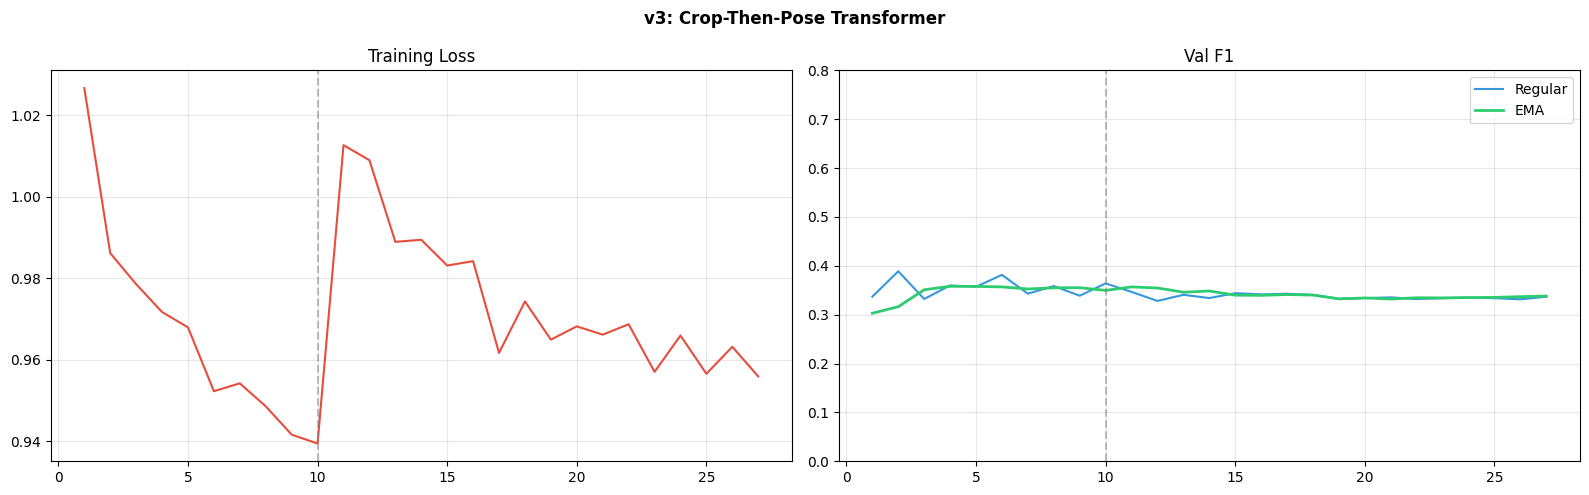

In [6]:
SAVE_PATH = str(Path(SAVE_DIR) / 'best.pt')
SAVE_EMA  = str(Path(SAVE_DIR) / 'best_ema.pt')
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

train_ds = V3SkeletonDataset(SKEL_ROOT_V3, 'train', TARGET_CLASSES,
                              augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
val_ds   = V3SkeletonDataset(SKEL_ROOT_V3, 'val', TARGET_CLASSES,
                              augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}')

counts = [len(list((Path(SKEL_ROOT_V3)/'train'/c).glob('*.npy'))) for c in TARGET_CLASSES]
total = sum(counts)
wts = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)
print(f'Weights: {dict(zip(TARGET_CLASSES, [round(w,3) for w in wts.tolist()]))}')

model = SkeletonTransformer(FEAT_DIM).to(DEVICE)
ema = EMA(model, EMA_DECAY)
criterion = nn.CrossEntropyLoss(weight=wts)

head_params = list(model.head.parameters()) + list(model.norm.parameters())
body_params = [p for n,p in model.named_parameters() if not any(x in n for x in ['head','norm'])]
for p in body_params:
    p.requires_grad = False

optimizer = optim.AdamW(head_params, lr=LR_HEAD, weight_decay=1e-2)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)

print()
print('='*70)
print('  Skeleton-Transformer v3 — Crop-Then-Pose Data')
print(f'  Stage 1 (ep 1-{FREEZE_EPOCHS}): head only, lr={LR_HEAD}')
print(f'  Stage 2 (ep {FREEZE_EPOCHS+1}+): full, lr={LR_FULL}')
print('='*70)
sys.stdout.flush()

best_f1, best_f1_ema, pat = 0.0, 0.0, 0
history = {'loss': [], 'f1': [], 'f1_ema': []}
best_yt, best_yp, best_yt_e, best_yp_e = [], [], [], []
t0 = time.time()

for epoch in range(1, EPOCHS+1):
    if epoch == FREEZE_EPOCHS+1:
        print(f'\n  >>> UNFREEZING (lr={LR_FULL}) <<<\n')
        for p in body_params: p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-2)
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)
        ema = EMA(model, EMA_DECAY)  # reset EMA after unfreeze

    model.train()
    tloss = 0.0
    for clips, labels in train_ld:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        if epoch > FREEZE_EPOCHS and MIXUP_ALPHA > 0:
            clips_m, ya, yb, lam = skeleton_mixup(clips, labels, MIXUP_ALPHA)
            optimizer.zero_grad()
            loss = lam*criterion(model(clips_m),ya) + (1-lam)*criterion(model(clips_m),yb)
        else:
            optimizer.zero_grad()
            loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)
        tloss += loss.item()
    tloss /= len(train_ld)
    scheduler.step()

    # Val — regular
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for c, l in val_ld:
            yp.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
            yt.extend(l.numpy())
    vf1 = f1_score(yt, yp, average='weighted', zero_division=0)

    # Val — EMA
    bk = ema.apply(model)
    yte, ype = [], []
    with torch.no_grad():
        for c, l in val_ld:
            ype.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
            yte.extend(l.numpy())
    vf1e = f1_score(yte, ype, average='weighted', zero_division=0)
    ema.restore(model, bk)

    history['loss'].append(tloss); history['f1'].append(vf1); history['f1_ema'].append(vf1e)

    imp = ''
    if vf1 > best_f1:
        best_f1, pat = vf1, 0
        best_yt, best_yp = yt, yp
        torch.save(model.state_dict(), SAVE_PATH)
        imp = ' ✅'
    else:
        pat += 1
    if vf1e > best_f1_ema:
        best_f1_ema = vf1e
        best_yt_e, best_yp_e = yte, ype
        bk2 = ema.apply(model)
        torch.save(model.state_dict(), SAVE_EMA)
        ema.restore(model, bk2)
        imp += ' ✅(ema)'

    elapsed = time.time() - t0
    stage = 'HEAD' if epoch <= FREEZE_EPOCHS else 'FULL'
    if epoch<=5 or epoch==FREEZE_EPOCHS or epoch==FREEZE_EPOCHS+1 or epoch%10==0 or imp or pat>=PATIENCE-3:
        m, s = divmod(int(elapsed), 60)
        print(f'  ep {epoch:>3} [{stage}] loss={tloss:.4f} f1={vf1:.4f} ema={vf1e:.4f} {m}m{s:02d}s{imp}')
        sys.stdout.flush()

    if pat >= PATIENCE and epoch > FREEZE_EPOCHS+10:
        print(f'  Early stop at epoch {epoch}')
        break

m, s = divmod(int(time.time()-t0), 60)
print(f'\nDone in {m}m{s:02d}s')
print(f'Best F1: {best_f1:.4f} | Best EMA: {best_f1_ema:.4f}')

fig, axes = plt.subplots(1,2,figsize=(16,5))
ep_x = range(1, len(history['loss'])+1)
axes[0].plot(ep_x, history['loss'], '-', color='#E74C3C', linewidth=1.5)
axes[0].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5)
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)
axes[1].plot(ep_x, history['f1'], '-', color='#3498DB', linewidth=1.5, label='Regular')
axes[1].plot(ep_x, history['f1_ema'], '-', color='#2ECC71', linewidth=2, label='EMA')
axes[1].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title('Val F1'); axes[1].set_ylim(0,0.8); axes[1].grid(alpha=0.3); axes[1].legend()
plt.suptitle('v3: Crop-Then-Pose Transformer', fontweight='bold')
plt.tight_layout(); plt.show()


  SKELETON-TRANSFORMER v3 RESULTS (Regular)
  Accuracy:      0.3964
  Weighted F1:   0.3888
  Violence:      prec=0.425  rec=0.264
  Threat:        prec=0.361  rec=0.467
  Normal:        prec=0.403  rec=0.492

              precision    recall  f1-score   support

    Violence       0.43      0.26      0.33       800
      Threat       0.36      0.47      0.41       450
      Normal       0.40      0.49      0.44       778

    accuracy                           0.40      2028
   macro avg       0.40      0.41      0.39      2028
weighted avg       0.40      0.40      0.39      2028

  COMPLETE M4-B COMPARISON — All Approaches
  Approach                                        Params     F1  VioR  ThrR  NorR
  ------------------------------------------------------------------------------
  YOLO frame-level (baseline)                       5.1M  0.486  0.65  0.72  0.31
  CNN+LSTM v1 (pixels)                              2.3M  0.669  0.65  0.43  0.79
  CNN+LSTM v3 (pixels, deployed)      

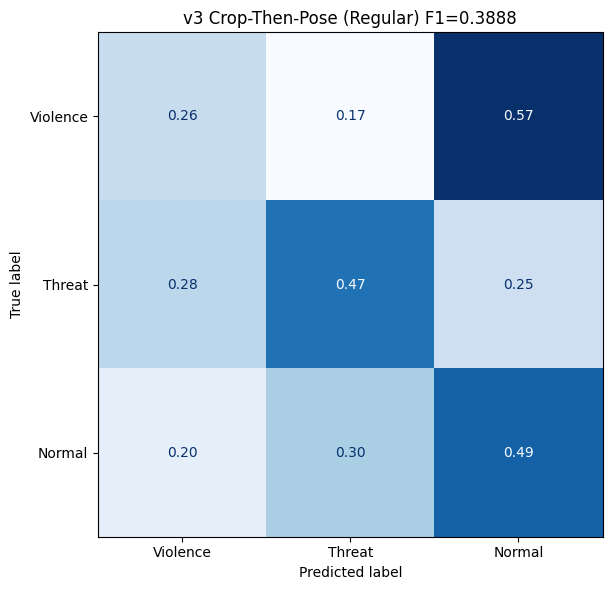


📊 Result: 0.389 (prev best: 0.579, CNN+LSTM: 0.638)

Weights: runs\M4B_classifier\TransformerV3\best.pt


In [7]:
def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

use_ema = best_f1_ema > best_f1
yt_f = np.array(best_yt_e if use_ema else best_yt)
yp_f = np.array(best_yp_e if use_ema else best_yp)
f1_f = best_f1_ema if use_ema else best_f1
tag = 'EMA' if use_ema else 'Regular'

print('='*85)
print(f'  SKELETON-TRANSFORMER v3 RESULTS ({tag})')
print('='*85)
print(f'  Accuracy:      {accuracy_score(yt_f, yp_f):.4f}')
print(f'  Weighted F1:   {f1_f:.4f}')
print(f'  Violence:      prec={get_m(yt_f,yp_f,"Violence","precision"):.3f}  rec={get_m(yt_f,yp_f,"Violence"):.3f}')
print(f'  Threat:        prec={get_m(yt_f,yp_f,"Threat","precision"):.3f}  rec={get_m(yt_f,yp_f,"Threat"):.3f}')
print(f'  Normal:        prec={get_m(yt_f,yp_f,"Normal","precision"):.3f}  rec={get_m(yt_f,yp_f,"Normal"):.3f}')
print('='*85)

print('\n' + classification_report(yt_f, yp_f, target_names=TARGET_CLASSES, zero_division=0))

# Full project comparison
print('='*95)
print('  COMPLETE M4-B COMPARISON — All Approaches')
print('='*95)
print(f'  {"Approach":<46} {"Params":>7} {"F1":>6} {"VioR":>5} {"ThrR":>5} {"NorR":>5}')
print('  ' + '-'*78)
rows = [
    ('YOLO frame-level (baseline)',             '5.1M', 0.486, 0.65, 0.72, 0.31),
    ('CNN+LSTM v1 (pixels)',                    '2.3M', 0.669, 0.65, 0.43, 0.79),
    ('CNN+LSTM v3 (pixels, deployed)',          '2.3M', 0.638, 0.57, 0.26, 0.92),
    ('CNN+LSTM v4 (non-overlapping)',           '2.3M', 0.483, 0.47, 0.38, 0.54),
    ('Skeleton-LSTM v1 (single person)',        '119K', 0.544, 0.80, 0.38, 0.48),
    ('Skeleton-LSTM v2 (multi-person)',         '386K', 0.550, 0.81, 0.59, 0.37),
    ('Skeleton-Transformer (arch search)',      '312K', 0.553, 0.62, 0.65, 0.43),
    ('Skeleton-Transformer B (best tuned)',     '577K', 0.579, 0.73, 0.55, 0.48),
    ('Skeleton-Transformer E (reg, best Thr)',  '1.2M', 0.578, 0.65, 0.70, 0.44),
]
for name, p, f, vr, tr, nr in rows:
    print(f'  {name:<46} {p:>7} {f:>6.3f} {vr:>5.2f} {tr:>5.2f} {nr:>5.2f}')

vr = get_m(yt_f,yp_f,'Violence')
tr = get_m(yt_f,yp_f,'Threat')
nr = get_m(yt_f,yp_f,'Normal')
print(f'  {"Skeleton-Transformer v3 (crop-then-pose)":<46} {"577K":>7} {f1_f:>6.3f} {vr:>5.2f} {tr:>5.2f} {nr:>5.2f}  ← NEW')
print('='*95)

# Confusion matrix
fig, ax = plt.subplots(figsize=(7,6))
cm = confusion_matrix(yt_f, yp_f)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
    ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title(f'v3 Crop-Then-Pose ({tag}) F1={f1_f:.4f}')
plt.tight_layout(); plt.show()

# Verdict
print()
prev = 0.579
cnn = 0.638
if f1_f > cnn:
    print(f'🏆 v3 BEATS CNN+LSTM v3! ({f1_f:.3f} vs {cnn:.3f})')
elif f1_f > prev + 0.01:
    print(f'📈 Improved: {prev:.3f} → {f1_f:.3f} (+{f1_f-prev:.3f})')
    print(f'   Gap to CNN+LSTM: {cnn-f1_f:.3f}')
else:
    print(f'📊 Result: {f1_f:.3f} (prev best: {prev:.3f}, CNN+LSTM: {cnn:.3f})')

path_used = SAVE_EMA if use_ema else SAVE_PATH
print(f'\nWeights: {path_used}')


## Skeleton-Transformer v3-fixed — Crop-Then-Pose with Balanced Classes

Re-extracts skeleton data with crop-then-pose but **without aggressive quality filtering** that destroyed the class balance in the previous v3.

**What went wrong in v3:**
The quality filter (avg_conf > 0.35) removed 58% of Violence and 59% of Threat clips but 0% of Normal. This created a 1:1:3.7 class ratio that made the model predict Normal for everything. F1 dropped from 0.579 to 0.389.

**What's fixed:**
- Quality filter threshold lowered from 0.35 to 0.10 (only reject truly empty clips)
- Person visibility requirement lowered from 60% to 40%
- MAX_CLIPS enforced per class to guarantee balance
- Crop-then-pose still applied (better upper body keypoints)
- Temporal smoothing + confidence weighting kept (they don't remove clips)

**What's kept from v3 that worked:**
- Crop-then-pose extraction (avg confidence 0.54 vs 0.35 in v2)
- Temporal smoothing (reduces frame-to-frame jitter)
- Confidence-weighted features (unreliable joints contribute less)
- Staged training + EMA

In [1]:
import os, cv2, gc, random, time, sys, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

DATASET_ROOT     = r'../Anomaly_Videos'
SKEL_ROOT        = r'../M4B_skeleton_clips_v3_fixed'
M2_WEIGHTS       = r'runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt'

TARGET_CLASSES   = ['Violence', 'Threat', 'Normal']
CLASS_FOLDER_MAP = {
    'Violence': ['Abuse', 'Assault', 'Fighting'],
    'Threat':   ['Arson', 'Explosion', 'Burglary', 'Arrest'],
    'Normal':   ['Normal-Videos-Part-1'],
}

SKEL_CLIP_FRAMES = 16
SKEL_CLIP_STRIDE = 16
MAX_PERSONS      = 2
N_KEYPOINTS      = 17
CROP_SIZE        = 256
MIN_AVG_CONF     = 0.10     # LOWERED from 0.35 — only reject truly empty clips
MIN_VISIBILITY   = 0.40     # LOWERED from 0.60 — keep more clips
TEMPORAL_SMOOTH  = 0.3

SKEL_MAX_CLIPS = {'Violence': 3000, 'Threat': 3000, 'Normal': 5000}
SKEL_TRAIN_RATIO = 0.80

EPOCHS        = 100
BATCH         = 32
LR_HEAD       = 1e-3
LR_FULL       = 5e-5
FREEZE_EPOCHS = 10
PATIENCE      = 25
EMA_DECAY     = 0.998
MIXUP_ALPHA   = 0.3
SAVE_DIR      = r'runs/M4B_classifier/TransformerV3_fixed'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Quality filter: avg_conf > {MIN_AVG_CONF} (v3 was 0.35)')
print(f'Visibility req: {MIN_VISIBILITY*100:.0f}% (v3 was 60%)')
print(f'Max clips: {SKEL_MAX_CLIPS} (balanced)')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Quality filter: avg_conf > 0.1 (v3 was 0.35)
Visibility req: 40% (v3 was 60%)
Max clips: {'Violence': 3000, 'Threat': 3000, 'Normal': 5000} (balanced)


In [2]:
def find_class_videos(dataset_root, class_name):
    root = Path(dataset_root)
    videos = []
    folders = CLASS_FOLDER_MAP.get(class_name, [class_name])
    for folder_name in folders:
        for folder in root.rglob('*'):
            if folder.is_dir() and folder.name == folder_name:
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
            elif folder.is_dir() and folder_name.lower() in folder.name.lower():
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
    return sorted(set(videos))

print('Scanning dataset...')
class_videos = {}
for cls in TARGET_CLASSES:
    vids = find_class_videos(DATASET_ROOT, cls)
    class_videos[cls] = vids
    print(f'  {cls:<12} {len(vids):>4} videos')
print(f'  {"TOTAL":<12} {sum(len(v) for v in class_videos.values()):>4} videos')


Scanning dataset...
  Violence      150 videos
  Threat        250 videos
  Normal        150 videos
  TOTAL         550 videos


### Crop-then-pose extraction (balanced version)

Same pipeline as v3 but with relaxed quality thresholds so anomaly clips aren't disproportionately removed.

In [3]:
from ultralytics import YOLO

print('Loading models...')
m2_model = YOLO(M2_WEIGHTS)
pose_model = YOLO('yolov8n-pose.pt')
print('Both models loaded ✅\n')

def detect_persons_m2(frame, model, conf=0.35):
    res = model(frame, conf=conf, iou=0.45, classes=[0], verbose=False)[0]
    boxes = []
    if res.boxes is not None:
        for b in res.boxes:
            x1, y1, x2, y2 = map(int, b.xyxy[0].cpu().numpy())
            boxes.append((x1, y1, x2, y2, float(b.conf[0])))
    return boxes

def extract_pose_from_crop(crop, pose_model):
    h_orig, w_orig = crop.shape[:2]
    if h_orig < 10 or w_orig < 10:
        return None
    resized = cv2.resize(crop, (CROP_SIZE, CROP_SIZE))
    results = pose_model(resized, verbose=False, conf=0.2)[0]
    if results.keypoints is None or len(results.keypoints) == 0:
        return None
    kp_data = results.keypoints.data
    if kp_data.shape[0] == 0:
        return None
    vis = kp_data[:, :, 2].sum(dim=1)
    best = vis.argmax().item()
    kps = kp_data[best].cpu().numpy()
    kps[:, 0] /= CROP_SIZE
    kps[:, 1] /= CROP_SIZE
    return kps

def temporal_smooth(skeletons, alpha=TEMPORAL_SMOOTH):
    if alpha <= 0 or len(skeletons) < 2:
        return skeletons
    smoothed = [skeletons[0].copy()]
    for i in range(1, len(skeletons)):
        s = smoothed[-1].copy()
        curr = skeletons[i]
        for p in range(curr.shape[0]):
            for j in range(curr.shape[1]):
                if curr[p, j, 2] > 0.15 and s[p, j, 2] > 0.15:
                    s[p, j, 0] = alpha * s[p, j, 0] + (1-alpha) * curr[p, j, 0]
                    s[p, j, 1] = alpha * s[p, j, 1] + (1-alpha) * curr[p, j, 1]
                    s[p, j, 2] = curr[p, j, 2]
                else:
                    s[p, j] = curr[p, j]
        smoothed.append(s)
    return smoothed

def extract_clips_v3_fixed(video_path, m2_model, pose_model):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []
    h_frame = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 720
    w_frame = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 1280

    all_skels = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        h_frame, w_frame = frame.shape[:2]
        person_boxes = detect_persons_m2(frame, m2_model)
        person_boxes.sort(key=lambda b: (b[2]-b[0])*(b[3]-b[1]), reverse=True)

        frame_skel = np.zeros((MAX_PERSONS, N_KEYPOINTS, 3), dtype=np.float32)
        for pi, (x1, y1, x2, y2, _) in enumerate(person_boxes[:MAX_PERSONS]):
            pad_x = int((x2-x1) * 0.15)
            pad_y = int((y2-y1) * 0.1)
            cx1 = max(0, x1-pad_x)
            cy1 = max(0, y1-pad_y)
            cx2 = min(w_frame, x2+pad_x)
            cy2 = min(h_frame, y2+pad_y)
            crop = frame[cy1:cy2, cx1:cx2]
            kps = extract_pose_from_crop(crop, pose_model)
            if kps is not None:
                frame_skel[pi] = kps
        all_skels.append(frame_skel)
    cap.release()

    if len(all_skels) < SKEL_CLIP_FRAMES:
        return []

    all_skels = temporal_smooth(all_skels, TEMPORAL_SMOOTH)

    clips = []
    for start in range(0, len(all_skels) - SKEL_CLIP_FRAMES + 1, SKEL_CLIP_STRIDE):
        clip = np.stack(all_skels[start:start+SKEL_CLIP_FRAMES])
        avg_conf = clip[:, 0, :, 2].mean()
        p1_vis = (clip[:, 0, :, 2].sum(axis=1) > 0).sum()
        if avg_conf >= MIN_AVG_CONF and p1_vis >= SKEL_CLIP_FRAMES * MIN_VISIBILITY:
            clips.append(clip.astype(np.float32))
    return clips


# ── Run extraction ────────────────────────────────────────────────────────────
print('='*70)
print('  CROP-THEN-POSE EXTRACTION (balanced)')
print(f'  Quality: avg_conf > {MIN_AVG_CONF}, visibility > {MIN_VISIBILITY*100:.0f}%')
print(f'  Max clips: {SKEL_MAX_CLIPS}')
print('='*70)
print()

skel_stats = {}
for cls in TARGET_CLASSES:
    train_dir = Path(SKEL_ROOT) / 'train' / cls
    val_dir   = Path(SKEL_ROOT) / 'val' / cls

    if train_dir.exists() and val_dir.exists():
        n_t = len(list(train_dir.glob('*.npy')))
        n_v = len(list(val_dir.glob('*.npy')))
        if n_t > 0 and n_v > 0:
            print(f'  {cls}: already extracted (train={n_t:,}  val={n_v:,}) ✅')
            skel_stats[cls] = {'train': n_t, 'val': n_v}
            continue

    videos = class_videos[cls]
    random.seed(42)
    shuffled = list(videos)
    random.shuffle(shuffled)
    n_train = max(1, int(len(shuffled) * SKEL_TRAIN_RATIO))
    train_vids = shuffled[:n_train]
    val_vids = shuffled[n_train:]

    max_cap = SKEL_MAX_CLIPS.get(cls, 3000)
    max_train = int(max_cap * SKEL_TRAIN_RATIO)
    max_val = max_cap - max_train

    print(f'  {cls} ({len(videos)} videos)...')

    for split, vid_list, split_cap in [('train', train_vids, max_train),
                                         ('val', val_vids, max_val)]:
        out_dir = Path(SKEL_ROOT) / split / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        split_total = 0
        for vpath in tqdm(vid_list, desc=f'    {split}', file=sys.stdout, leave=False):
            clips = extract_clips_v3_fixed(vpath, m2_model, pose_model)
            for ci, clip in enumerate(clips):
                if split_total >= split_cap:
                    break
                np.save(str(out_dir / f'{vpath.stem[:25]}_s{ci:04d}.npy'), clip)
                split_total += 1
            if split_total >= split_cap:
                break

    t = len(list((Path(SKEL_ROOT)/'train'/cls).glob('*.npy')))
    v = len(list((Path(SKEL_ROOT)/'val'/cls).glob('*.npy')))
    skel_stats[cls] = {'train': t, 'val': v}
    print(f'    → train={t:,}  val={v:,}')

print()
print('='*60)
total_t = total_v = 0
for cls in TARGET_CLASSES:
    t, v = skel_stats[cls]['train'], skel_stats[cls]['val']
    total_t += t; total_v += v
    print(f'  {cls:<12} train={t:>6,}  val={v:>6,}')
print(f'  {"TOTAL":<12} train={total_t:>6,}  val={total_v:>6,}')

# Check balance
counts = [skel_stats[c]['train'] for c in TARGET_CLASSES]
ratio = max(counts) / min(counts) if min(counts) > 0 else float('inf')
print(f'\n  Class ratio (max/min): {ratio:.1f}x', end='')
if ratio < 2.0:
    print(' ✅ balanced')
elif ratio < 3.0:
    print(' ⚠ slightly imbalanced')
else:
    print(' ❌ imbalanced — check extraction')
print('='*60)

del m2_model, pose_model
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('\nModels released ✅')


Loading models...
Both models loaded ✅

  CROP-THEN-POSE EXTRACTION (balanced)
  Quality: avg_conf > 0.1, visibility > 40%
  Max clips: {'Violence': 3000, 'Threat': 3000, 'Normal': 5000}

  Violence (150 videos)...
    → train=2,400  val=600                                    
  Threat (250 videos)...
    → train=2,400  val=600                                      
  Normal (150 videos)...
    → train=4,000  val=1,000                                  

  Violence     train= 2,400  val=   600
  Threat       train= 2,400  val=   600
  Normal       train= 4,000  val= 1,000
  TOTAL        train= 8,800  val= 2,200

  Class ratio (max/min): 1.7x ✅ balanced

Models released ✅


In [4]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)

class BalancedSkeletonDataset(Dataset):
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples = []
        self.augment = augment
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def _mask_low_conf(self, clip):
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.2
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(clip.shape[0]):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp
                        clip[t, p, j, 2] = 0.0
        return clip

    def _build(self, clip):
        T = clip.shape[0]
        clip = self._mask_low_conf(clip)
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                conf = k[:, 2]
                pos_w = k[:, :2] * conf[:, None]
                f.extend([pos_w.flatten(), conf, compute_bones(k), compute_angles(k)])
            f.append(compute_inter(clip[t,0], clip[t,1]))
            rows.append(np.concatenate(f))
        feat = np.stack(rows)
        psize = 34+17+16+5
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos); vel[1:] = pos[1:]-pos[:-1]
            acc = np.zeros_like(vel); acc[2:] = vel[2:]-vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)
        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)
        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label

print('Computing feature statistics...')
tmp = BalancedSkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES)
if len(tmp) == 0:
    print('ERROR: No clips found')
else:
    samps = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
    af = np.concatenate(samps, axis=0)
    FEAT_MEAN = af.mean(axis=0)
    FEAT_STD  = af.std(axis=0)
    FEAT_DIM  = FEAT_MEAN.shape[0]
    del samps, af
    
    # Quality check
    confs = []
    for i in range(min(500, len(tmp))):
        c = np.load(str(tmp.samples[i][0]))
        confs.append(c[:, 0, :, 2].mean())
    print(f'Feature dim: {FEAT_DIM}')
    print(f'Avg keypoint confidence: {np.mean(confs):.3f}')
    print(f'  v2 (full-frame pose): ~0.35')
    print(f'  v3 (crop-then-pose):  {np.mean(confs):.3f}')
del tmp
print('✅')


Computing feature statistics...
Feature dim: 283
Avg keypoint confidence: 0.444
  v2 (full-frame pose): ~0.35
  v3 (crop-then-pose):  0.444
✅


In [5]:
class SkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=4, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model), nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3))
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(d_model, d_model//2),
            nn.GELU(), nn.Dropout(dropout*0.5), nn.Linear(d_model//2, num_classes))
    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        x = torch.cat([self.cls_token.expand(B,-1,-1), x], dim=1)
        pos = torch.cat([torch.zeros(1,1,x.shape[2],device=x.device), self.pos_embed], dim=1)
        x = self.transformer(x + pos)
        return self.head(self.norm(x[:, 0]))

class EMA:
    def __init__(self, model, decay=0.998):
        self.decay = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n] = self.decay * self.shadow[n] + (1-self.decay) * p.data
    def apply(self, model):
        bk = {}
        for n, p in model.named_parameters():
            if n in self.shadow:
                bk[n] = p.data.clone(); p.data = self.shadow[n].clone()
        return bk
    def restore(self, model, bk):
        for n, p in model.named_parameters():
            if n in bk: p.data = bk[n]

def skeleton_mixup(x, y, alpha=0.3):
    lam = max(np.random.beta(alpha, alpha), 0.5)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

print(f'Model: Config B, {sum(p.numel() for p in SkeletonTransformer(FEAT_DIM).parameters()):,} params')


Model: Config B, 577,411 params


C:\Users\jingy\AppData\Local\Temp\ipykernel_21780\2466049115.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


Train: 8,800  Val: 2,200
Weights: {'Violence': 1.222, 'Threat': 1.222, 'Normal': 0.733}
  (v3-broken had: Vio=1.86, Thr=1.90, Nor=0.52 — too extreme)

  Skeleton-Transformer v3-fixed
  Crop-then-pose data with balanced classes
  Stage 1 (ep 1-10): head only, lr=0.001
  Stage 2 (ep 11+): full, lr=5e-05


C:\Users\jingy\AppData\Local\Temp\ipykernel_21780\2466049115.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  ep   1 [HEAD] loss=1.0203 f1=0.4254 ema=0.4143 1m29s ✅ ✅(ema)
  ep   2 [HEAD] loss=0.9733 f1=0.4545 ema=0.4236 2m30s ✅ ✅(ema)
  ep   3 [HEAD] loss=0.9752 f1=0.4526 ema=0.4483 3m33s ✅(ema)
  ep   4 [HEAD] loss=0.9553 f1=0.4792 ema=0.4520 4m35s ✅ ✅(ema)
  ep   5 [HEAD] loss=0.9561 f1=0.4726 ema=0.4610 5m37s ✅(ema)
  ep   8 [HEAD] loss=0.9407 f1=0.4466 ema=0.4635 8m41s ✅(ema)
  ep  10 [HEAD] loss=0.9341 f1=0.4354 ema=0.4578 10m45s

  >>> UNFREEZING (lr=5e-05) <<<

  ep  11 [FULL] loss=1.0019 f1=0.3863 ema=0.4172 11m55s
  ep  20 [FULL] loss=0.9473 f1=0.3886 ema=0.3946 22m30s
  ep  26 [FULL] loss=0.9411 f1=0.3764 ema=0.3911 29m36s
  ep  27 [FULL] loss=0.9374 f1=0.3772 ema=0.3930 30m46s
  ep  28 [FULL] loss=0.9303 f1=0.3806 ema=0.3868 31m57s
  ep  29 [FULL] loss=0.9375 f1=0.3828 ema=0.3929 33m07s
  Early stop at epoch 29

Done in 33m07s
Best F1: 0.4792 | Best EMA: 0.4635


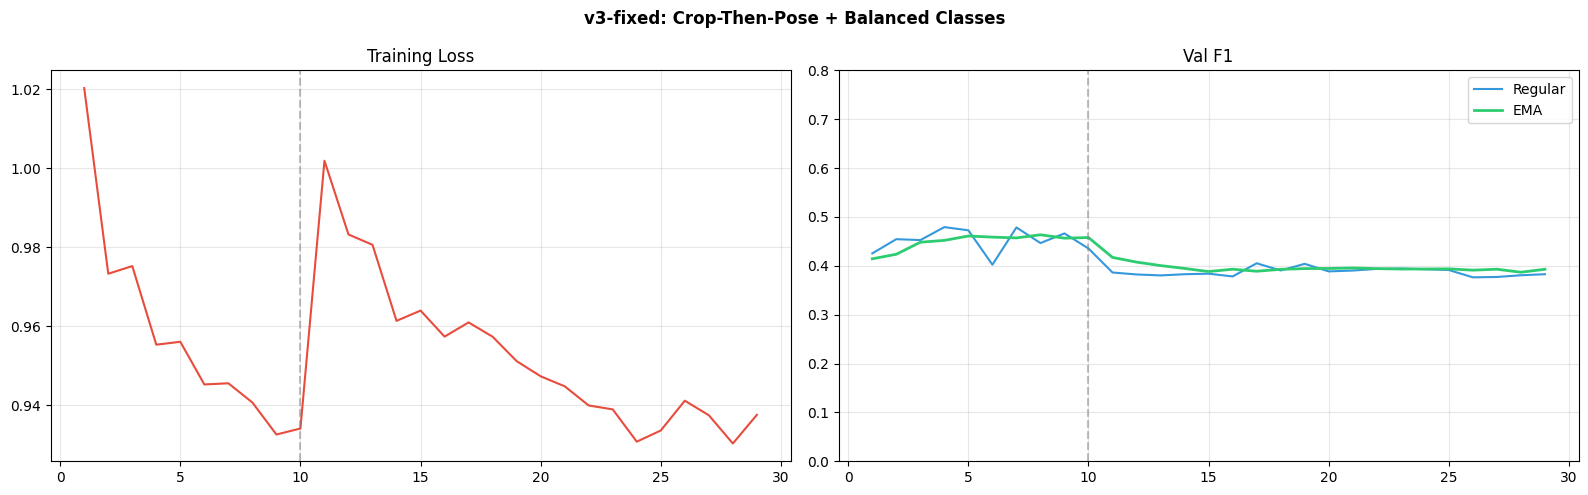

In [6]:
SAVE_PATH = str(Path(SAVE_DIR) / 'best.pt')
SAVE_EMA  = str(Path(SAVE_DIR) / 'best_ema.pt')
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

train_ds = BalancedSkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES,
                                    augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
val_ds   = BalancedSkeletonDataset(SKEL_ROOT, 'val', TARGET_CLASSES,
                                    augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}')

counts = [len(list((Path(SKEL_ROOT)/'train'/c).glob('*.npy'))) for c in TARGET_CLASSES]
total = sum(counts)
wts = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)
print(f'Weights: {dict(zip(TARGET_CLASSES, [round(w,3) for w in wts.tolist()]))}')
print(f'  (v3-broken had: Vio=1.86, Thr=1.90, Nor=0.52 — too extreme)')

model = SkeletonTransformer(FEAT_DIM).to(DEVICE)
ema = EMA(model, EMA_DECAY)
criterion = nn.CrossEntropyLoss(weight=wts)

head_params = list(model.head.parameters()) + list(model.norm.parameters())
body_params = [p for n,p in model.named_parameters() if not any(x in n for x in ['head','norm'])]
for p in body_params: p.requires_grad = False

optimizer = optim.AdamW(head_params, lr=LR_HEAD, weight_decay=1e-2)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)

print()
print('='*70)
print('  Skeleton-Transformer v3-fixed')
print(f'  Crop-then-pose data with balanced classes')
print(f'  Stage 1 (ep 1-{FREEZE_EPOCHS}): head only, lr={LR_HEAD}')
print(f'  Stage 2 (ep {FREEZE_EPOCHS+1}+): full, lr={LR_FULL}')
print('='*70)
sys.stdout.flush()

best_f1, best_ema, pat = 0.0, 0.0, 0
history = {'loss': [], 'f1': [], 'f1_ema': []}
best_yt, best_yp, best_yte, best_ype = [], [], [], []
t0 = time.time()

for epoch in range(1, EPOCHS+1):
    if epoch == FREEZE_EPOCHS+1:
        print(f'\n  >>> UNFREEZING (lr={LR_FULL}) <<<\n')
        for p in body_params: p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-2)
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)
        ema = EMA(model, EMA_DECAY)

    model.train()
    tloss = 0.0
    for clips, labels in train_ld:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        if epoch > FREEZE_EPOCHS and MIXUP_ALPHA > 0:
            cm, ya, yb, lam = skeleton_mixup(clips, labels, MIXUP_ALPHA)
            optimizer.zero_grad()
            loss = lam*criterion(model(cm),ya) + (1-lam)*criterion(model(cm),yb)
        else:
            optimizer.zero_grad()
            loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)
        tloss += loss.item()
    tloss /= len(train_ld)
    scheduler.step()

    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for c, l in val_ld:
            yp.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
            yt.extend(l.numpy())
    vf1 = f1_score(yt, yp, average='weighted', zero_division=0)

    bk = ema.apply(model)
    yte, ype = [], []
    with torch.no_grad():
        for c, l in val_ld:
            ype.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
            yte.extend(l.numpy())
    vfe = f1_score(yte, ype, average='weighted', zero_division=0)
    ema.restore(model, bk)

    history['loss'].append(tloss); history['f1'].append(vf1); history['f1_ema'].append(vfe)

    imp = ''
    if vf1 > best_f1:
        best_f1, pat = vf1, 0; best_yt, best_yp = yt, yp
        torch.save(model.state_dict(), SAVE_PATH); imp = ' ✅'
    else: pat += 1
    if vfe > best_ema:
        best_ema = vfe; best_yte, best_ype = yte, ype
        bk2 = ema.apply(model); torch.save(model.state_dict(), SAVE_EMA); ema.restore(model, bk2)
        imp += ' ✅(ema)'

    elapsed = time.time() - t0
    stage = 'HEAD' if epoch <= FREEZE_EPOCHS else 'FULL'
    if epoch<=5 or epoch==FREEZE_EPOCHS or epoch==FREEZE_EPOCHS+1 or epoch%10==0 or imp or pat>=PATIENCE-3:
        m, s = divmod(int(elapsed), 60)
        print(f'  ep {epoch:>3} [{stage}] loss={tloss:.4f} f1={vf1:.4f} ema={vfe:.4f} {m}m{s:02d}s{imp}')
        sys.stdout.flush()
    if pat >= PATIENCE and epoch > FREEZE_EPOCHS+10:
        print(f'  Early stop at epoch {epoch}'); break

m, s = divmod(int(time.time()-t0), 60)
print(f'\nDone in {m}m{s:02d}s')
print(f'Best F1: {best_f1:.4f} | Best EMA: {best_ema:.4f}')

fig, axes = plt.subplots(1,2,figsize=(16,5))
ex = range(1, len(history['loss'])+1)
axes[0].plot(ex, history['loss'], '-', color='#E74C3C', linewidth=1.5)
axes[0].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5)
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)
axes[1].plot(ex, history['f1'], '-', color='#3498DB', linewidth=1.5, label='Regular')
axes[1].plot(ex, history['f1_ema'], '-', color='#2ECC71', linewidth=2, label='EMA')
axes[1].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title('Val F1'); axes[1].set_ylim(0,0.8); axes[1].grid(alpha=0.3); axes[1].legend()
plt.suptitle('v3-fixed: Crop-Then-Pose + Balanced Classes', fontweight='bold')
plt.tight_layout(); plt.show()


  v3-FIXED RESULTS (Regular)
  Accuracy:      0.4759
  Weighted F1:   0.4792
  Violence:      prec=0.413  rec=0.443
  Threat:        prec=0.407  rec=0.548
  Normal:        prec=0.604  rec=0.452

              precision    recall  f1-score   support

    Violence       0.41      0.44      0.43       600
      Threat       0.41      0.55      0.47       600
      Normal       0.60      0.45      0.52      1000

    accuracy                           0.48      2200
   macro avg       0.47      0.48      0.47      2200
weighted avg       0.50      0.48      0.48      2200

  COMPLETE M4-B COMPARISON
  Approach                                        Params     F1  VioR  ThrR  NorR
  ------------------------------------------------------------------------------
  YOLO frame-level                                  5.1M  0.486  0.65  0.72  0.31
  CNN+LSTM v1 (pixels)                              2.3M  0.669  0.65  0.43  0.79
  CNN+LSTM v3 (deployed)                            2.3M  0.638  0.57 

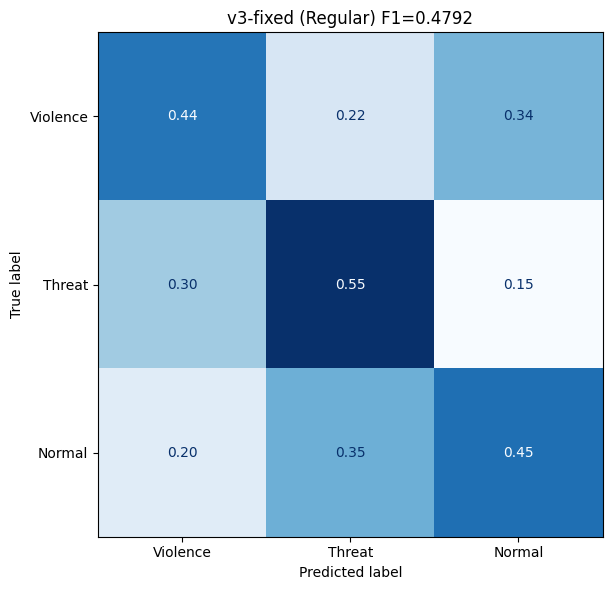


📈 Recovered from broken v3: 0.389 → 0.479
   Class balance was the critical issue

Weights: runs\M4B_classifier\TransformerV3_fixed\best.pt


In [7]:
def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

use_ema = best_ema > best_f1
yt_f = np.array(best_yte if use_ema else best_yt)
yp_f = np.array(best_ype if use_ema else best_yp)
f1_f = best_ema if use_ema else best_f1
tag = 'EMA' if use_ema else 'Regular'

print('='*85)
print(f'  v3-FIXED RESULTS ({tag})')
print('='*85)
print(f'  Accuracy:      {accuracy_score(yt_f, yp_f):.4f}')
print(f'  Weighted F1:   {f1_f:.4f}')
print(f'  Violence:      prec={get_m(yt_f,yp_f,"Violence","precision"):.3f}  rec={get_m(yt_f,yp_f,"Violence"):.3f}')
print(f'  Threat:        prec={get_m(yt_f,yp_f,"Threat","precision"):.3f}  rec={get_m(yt_f,yp_f,"Threat"):.3f}')
print(f'  Normal:        prec={get_m(yt_f,yp_f,"Normal","precision"):.3f}  rec={get_m(yt_f,yp_f,"Normal"):.3f}')
print('='*85)
print('\n' + classification_report(yt_f, yp_f, target_names=TARGET_CLASSES, zero_division=0))

print('='*95)
print('  COMPLETE M4-B COMPARISON')
print('='*95)
print(f'  {"Approach":<46} {"Params":>7} {"F1":>6} {"VioR":>5} {"ThrR":>5} {"NorR":>5}')
print('  ' + '-'*78)
for name, p, f, vr, tr, nr in [
    ('YOLO frame-level',                        '5.1M', 0.486, 0.65, 0.72, 0.31),
    ('CNN+LSTM v1 (pixels)',                    '2.3M', 0.669, 0.65, 0.43, 0.79),
    ('CNN+LSTM v3 (deployed)',                  '2.3M', 0.638, 0.57, 0.26, 0.92),
    ('Skeleton-LSTM v1',                        '119K', 0.544, 0.80, 0.38, 0.48),
    ('Skeleton-LSTM v2 (multi-person)',          '386K', 0.550, 0.81, 0.59, 0.37),
    ('Skeleton-Transformer B (v2 data)',         '577K', 0.579, 0.73, 0.55, 0.48),
    ('Skeleton-Transformer E (best Threat)',     '1.2M', 0.578, 0.65, 0.70, 0.44),
    ('Skeleton-Transformer v3 (broken balance)', '577K', 0.389, 0.26, 0.47, 0.49),
]:
    print(f'  {name:<46} {p:>7} {f:>6.3f} {vr:>5.2f} {tr:>5.2f} {nr:>5.2f}')

vr = get_m(yt_f,yp_f,'Violence')
tr = get_m(yt_f,yp_f,'Threat')
nr = get_m(yt_f,yp_f,'Normal')
print(f'  {"Skeleton-Transformer v3-fixed (this)":<46} {"577K":>7} {f1_f:>6.3f} {vr:>5.2f} {tr:>5.2f} {nr:>5.2f}  ← NEW')
print('='*95)

fig, ax = plt.subplots(figsize=(7,6))
cm = confusion_matrix(yt_f, yp_f)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
    ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title(f'v3-fixed ({tag}) F1={f1_f:.4f}')
plt.tight_layout(); plt.show()

print()
if f1_f > 0.638:
    print(f'🏆 BEATS CNN+LSTM v3! ({f1_f:.3f} vs 0.638)')
elif f1_f > 0.579:
    print(f'📈 New skeleton best: {f1_f:.3f} (prev: 0.579)')
    print(f'   Crop-then-pose + balanced classes worked!')
elif f1_f > 0.389:
    print(f'📈 Recovered from broken v3: {0.389:.3f} → {f1_f:.3f}')
    print(f'   Class balance was the critical issue')
else:
    print(f'📊 Result: {f1_f:.3f}')
print(f'\nWeights: {SAVE_EMA if use_ema else SAVE_PATH}')
